<img src="ost_logo.png" width="240" align="right"/>
<div style="text-align: left"> <b> Machine Learning </b> <br> MSE FTP MachLe <br> 
<a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

# Lab 4, A3: Yelp Business Classification using Bag-of-Words and tf-idf

Yelp is a crowd-sourced review forum, as well as an American multinational corporation headquartered in San Francisco, California. It develops, hosts and markets Yelp.com and the Yelp mobile app, which publish crowd-sourced reviews about local businesses, as well as the online reservation service Yelp Reservations. The company also trains small businesses in
how to respond to reviews, hosts social events for reviewers, and provides data about businesses, including health inspection scores. The data is open and can be downloaded here https://www.yelp.com/dataset/challenge.

We have prepared a partial dataset from the big Yelp dataset in the __pickle serialization format__ that you can read into a pandas dataframe using ``pd.read_pickle``.


In [42]:
import json
import numpy as np
import pandas as pd
from sklearn.feature_extraction import text
from sklearn.linear_model import LogisticRegression
import sklearn.model_selection as modsel
import sklearn.preprocessing as preproc

### (a)  Load and prep Yelp reviews data

In [43]:
nightlife_subset = pd.read_pickle('nightlife_subset.pkl')
restaurant_subset = pd.read_pickle('restaurant_subset.pkl')

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/pandas/compat/pickle_compat.py:80: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  stack[-1] = func(*args)
/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/pandas/compat/pickle_compat.py:80: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  stack[-1] = func(*args)
/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/pandas/compat/pickle_compat.py:80: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  stack[-1] = func(*args)
/Users/marbetschar/Development/

### (b) combine both datasets

In [44]:
combined = pd.concat([nightlife_subset, restaurant_subset])

In [45]:
combined['target'] = combined.apply(lambda x: 'Nightlife' in x['categories'],
                                    axis=1)

In [46]:
combined

,business_id,name,stars_y,text,categories,target
2203299,lpYFsXFrojiBZ1kbWR2lZw,Four Peaks Grill & Tap,5,Great service and food... Enjoy the atmosphere...,"Food, Restaurants, American (New), Local Flavo...",True
482774,KskYqH1Bi7Z_61pH6Om8pg,Lotus of Siam,5,Lotus is one of my all time favorites in Las V...,"Wine Bars, Nightlife, Restaurants, Seafood, Ca...",True
3086879,zFnPRtP7LGvr3sfxvy_dfg,Revolution Ale House,1,This place has definitely gone downhill. We fi...,"Nightlife, Italian, Restaurants, Pizza, Bars",True
512115,gUR2pWQKLPgMEm_R_aI_aw,Shooters On The Water,3,Thought this might be a worn out hang out for ...,"Dive Bars, American (New), American (Tradition...",True
3278073,hmYnzs8-aHbltaOOGDgmbA,Zipps Sports Grill,4,Zipps is almost always on happy hour! They hav...,"Sports Bars, American (Traditional), Nightlife...",True
...,...,...,...,...,...,...
2429937,Vs7gc9EE3k9wARuUcN9piA,Pan Asian,5,Pan Asian stays 5 stars for me. I went back t...,"Thai, Chinese, Japanese, Restaurants",False
640067,mYzlPKXvOVRrQivHnDqD5g,YamChops,5,Amazingly delicious with a variety of distinct...,"Butcher, Juice Bars & Smoothies, Vegan, Restau...",False
1566257,9Zl4uWSgSMpxHnsK_MPneg,Palermo Family Restaurant,4,"Eat here quite often, the Palermo Special piz...","Restaurants, Pizza",False
1607254,F-AYOq1xIY2u_qmWUG5VBw,Hakka Ren,5,It was amazing! I had the chilli fish schezuan...,"Chinese, Halal, Indian, Restaurants",False


In [47]:
print(combined.shape)

(20000, 6)


### (c) Split the dataset into a training and test set

In [48]:
# Split into training and test data sets
training_data, test_data = modsel.train_test_split(combined, 
                                                   train_size=0.7, 
                                                   random_state=123)

In [49]:
training_data.shape

(14000, 6)

In [50]:
test_data.shape

(6000, 6)

### (d) Transform the text as BoW (bag-of-words)

In [51]:
# Represent the review text as a bag-of-words 
bow_transform = text.CountVectorizer()
X_tr_bow = bow_transform.fit_transform(training_data['text'])

In [52]:
len(bow_transform.vocabulary_)

29944

In [53]:
X_tr_bow.shape

(14000, 29944)

In [54]:
X_te_bow = bow_transform.transform(test_data['text'])

In [55]:
y_tr = training_data['target']
y_te = test_data['target']

### (e,f) Classify with logistic regression

In [56]:
def simple_logistic_classify(X_tr, y_tr, X_test, y_test, description, _C=1.0):
    ## Helper function to train a logistic classifier and score on test data
    m = LogisticRegression(C=_C, solver='newton-cg',max_iter=500).fit(X_tr, y_tr)
    s = m.score(X_test, y_test)
    print ('Test score with', description, 'features:', s)
    return m

In [57]:
m1 = simple_logistic_classify(X_tr_bow, y_tr, X_te_bow, y_te, 'bow')

Test score with bow features: 0.7141666666666666


### (f) applying normalization to the features

In [58]:
X_tr_l2 = preproc.normalize(X_tr_bow, axis=0)
X_te_l2 = preproc.normalize(X_te_bow, axis=0)

In [59]:
m2 = simple_logistic_classify(X_tr_l2, y_tr, X_te_l2, y_te, 'l2-normalized')

Test score with l2-normalized features: 0.7398333333333333


### (g) tf-idf represenation

In [60]:
# Create the tf-idf representation using the bag-of-words matrix
tfidf_trfm = text.TfidfTransformer(norm=None)
X_tr_tfidf = tfidf_trfm.fit_transform(X_tr_bow)

In [61]:
X_te_tfidf = tfidf_trfm.transform(X_te_bow)

In [62]:
m3 = simple_logistic_classify(X_tr_tfidf, y_tr, X_te_tfidf, y_te, 'tf-idf')

Test score with tf-idf features: 0.6796666666666666


### (h) Tune regularization parameters using grid search

In [63]:
param_grid_ = {'C': [1e-5, 1e-3, 1e-1, 1e0, 1e1, 1e2]}
bow_search = modsel.GridSearchCV(LogisticRegression(solver='lbfgs',max_iter=1000),
                                 cv=5, param_grid=param_grid_, return_train_score=True)
l2_search  = modsel.GridSearchCV(LogisticRegression(solver='lbfgs',max_iter=1000),
                                 cv=5, return_train_score=True, param_grid=param_grid_)
tfidf_search = modsel.GridSearchCV(LogisticRegression(solver='lbfgs',max_iter=1000),
                                cv=5, return_train_score=True, param_grid=param_grid_)

In [64]:
bow_search.fit(X_tr_bow, y_tr)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1e-05, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [65]:
bow_search.best_score_

np.float64(0.7187857142857144)

In [66]:
l2_search.fit(X_tr_l2, y_tr)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1e-05, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [67]:
l2_search.best_score_

np.float64(0.7279285714285714)

In [68]:
tfidf_search.fit(X_tr_tfidf, y_tr)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1e-05, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [69]:
tfidf_search.best_score_

np.float64(0.7340714285714285)

What regularization parameters are best for each method?

In [70]:
bow_search.best_params_

{'C': 0.1}

In [71]:
l2_search.best_params_

{'C': 1.0}

In [72]:
tfidf_search.best_params_

{'C': 0.001}

Let's check one of the grid search outputs to see how it went:

In [73]:
bow_search.cv_results_

{'mean_fit_time': array([0.04795542, 0.06351824, 0.39045081, 0.8516048 , 1.21128058,
        1.35792499]),
 'std_fit_time': array([0.00136237, 0.0018833 , 0.05118553, 0.06888872, 0.0692935 ,
        0.10545552]),
 'mean_score_time': array([0.00068159, 0.00079403, 0.00066895, 0.00069318, 0.00066729,
        0.0006537 ]),
 'std_score_time': array([8.29612245e-05, 8.99106272e-05, 2.65865688e-05, 4.25152139e-05,
        1.34425799e-05, 1.11312628e-05]),
 'param_C': masked_array(data=[1e-05, 0.001, 0.1, 1.0, 10.0, 100.0],
              mask=[False, False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'C': 1e-05},
  {'C': 0.001},
  {'C': 0.1},
  {'C': 1.0},
  {'C': 10.0},
  {'C': 100.0}],
 'split0_test_score': array([0.56535714, 0.70428571, 0.71285714, 0.69642857, 0.67892857,
        0.66678571]),
 'split1_test_score': array([0.55035714, 0.71178571, 0.71964286, 0.70821429, 0.68178571,
        0.67      ]),
 'split2_test_score': array([0.57285714, 0.70892857, 0.71642857

In [74]:
import pickle

In [75]:
results_file = open('tfidf_gridcv_results.pkl', 'wb')
pickle.dump(bow_search, results_file, -1)
pickle.dump(tfidf_search, results_file, -1)
pickle.dump(l2_search, results_file, -1)
results_file.close()

In [76]:
pkl_file = open('tfidf_gridcv_results.pkl', 'rb')
bow_search = pickle.load(pkl_file)
tfidf_search = pickle.load(pkl_file)
l2_search = pickle.load(pkl_file)
pkl_file.close()

In [77]:
search_results = pd.DataFrame.from_dict({'bow': bow_search.cv_results_['mean_test_score'],
                               'tfidf': tfidf_search.cv_results_['mean_test_score'],
                               'l2': l2_search.cv_results_['mean_test_score']})
search_results

,bow,tfidf,l2
0,0.560500,0.701786,0.502500
1,0.711929,0.734071,0.502500
2,0.718786,0.692500,0.710857
3,0.703071,0.672786,0.727929
4,0.680714,0.669500,0.714857
5,0.667571,0.678571,0.700357


## Plot cross validation results

In [78]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

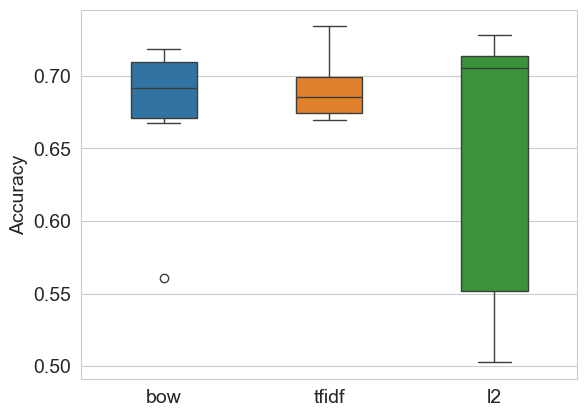

In [79]:
ax = sns.boxplot(data=search_results, width=0.4)
ax.set_ylabel('Accuracy', size=14)
ax.tick_params(labelsize=14)
plt.savefig('tfidf_gridcv_results.png')

In [80]:
m1 = simple_logistic_classify(X_tr_bow, y_tr, X_te_bow, y_te, 'bow', 
                              _C=bow_search.best_params_['C'])
m2 = simple_logistic_classify(X_tr_l2, y_tr, X_te_l2, y_te, 'l2-normalized', 
                              _C=l2_search.best_params_['C'])
m3 = simple_logistic_classify(X_tr_tfidf, y_tr, X_te_tfidf, y_te, 'tf-idf', 
                              _C=tfidf_search.best_params_['C'])

Test score with bow features: 0.7295
Test score with l2-normalized features: 0.7398333333333333
Test score with tf-idf features: 0.7413333333333333


In [81]:
bow_search.cv_results_['mean_test_score']

array([0.5605    , 0.71192857, 0.71878571, 0.70307143, 0.68071429,
       0.66757143])